# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression,Perceptron
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay




```

# Load Data

In [2]:
df = pd.read_csv("data.csv",sep=";")
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


# Data Cleaning, Information & Visualization

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [4]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [5]:
df.shape

(4424, 37)

In [6]:
df.size

163688

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [8]:
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [9]:
df['Target'] = LabelEncoder().fit_transform(df['Target'])

In [10]:
df['Target'].value_counts()

Target
2    2209
0    1421
1     794
Name: count, dtype: int64

C:\Users\praty\AppData\Local\Temp\ipykernel_6768\4238329413.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Target'], color = "Blue")


<Axes: xlabel='Target', ylabel='Count'>

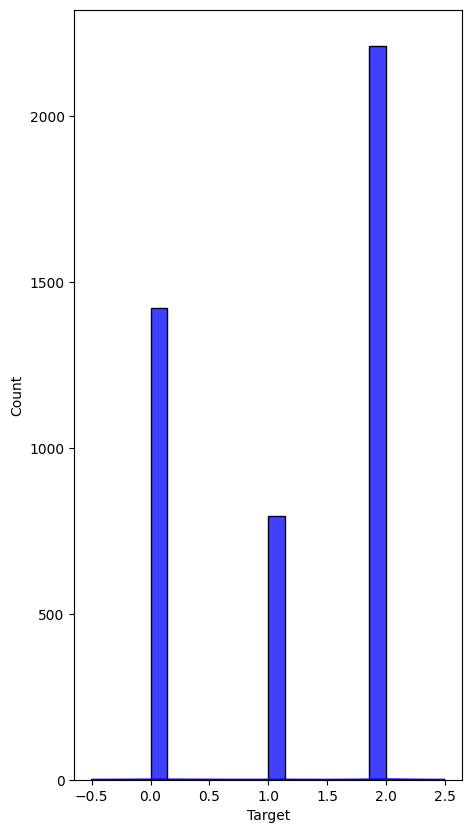

In [11]:
plt.figure(figsize=(5, 10))
sns.histplot(df['Target'], color = "Blue")
sns.distplot(df['Target'], color = "Blue")

Text(0.5, 1.0, 'Target')

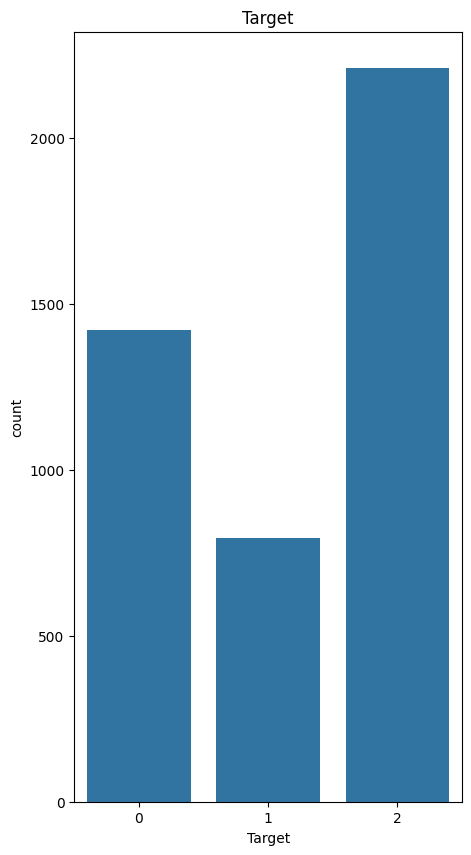

In [12]:
plt.figure(figsize=(5, 10))
sns.countplot(data = df, x="Target").set_title('Target')

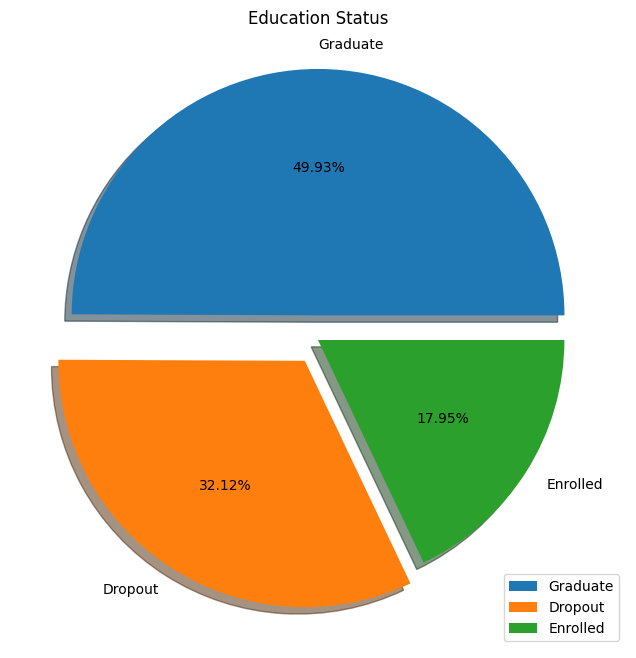

In [13]:
plt.figure(figsize=(8, 8))
plt.title("Education Status")
plt.pie(df['Target'].value_counts(), labels = ['Graduate', 'Dropout', 'Enrolled'], explode = (0.1, 0.1, 0.0), autopct='%1.2f%%', shadow = True)
plt.legend( loc = 'lower right')

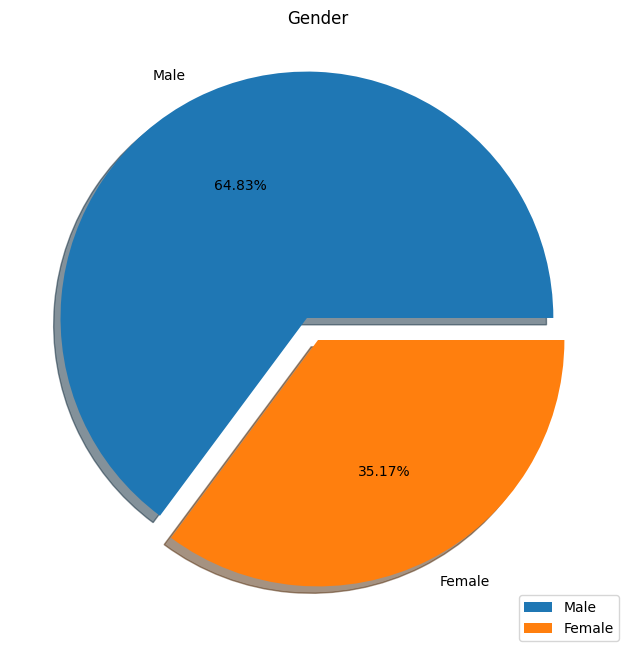

In [14]:
plt.figure(figsize=(8, 8))
plt.title("Gender")
plt.pie(df['Gender'].value_counts(), labels = ['Male', 'Female'], explode = (0.1, 0.0), autopct='%1.2f%%', shadow = True)
plt.legend( loc = 'lower right')

C:\Users\praty\AppData\Local\Temp\ipykernel_6768\3898062606.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.iloc[:, i], color='blue')
C:\Users\praty\AppData\Local\Temp\ipykernel_6768\3898062606.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.iloc[:, i], color='blue')
C:\Users\praty

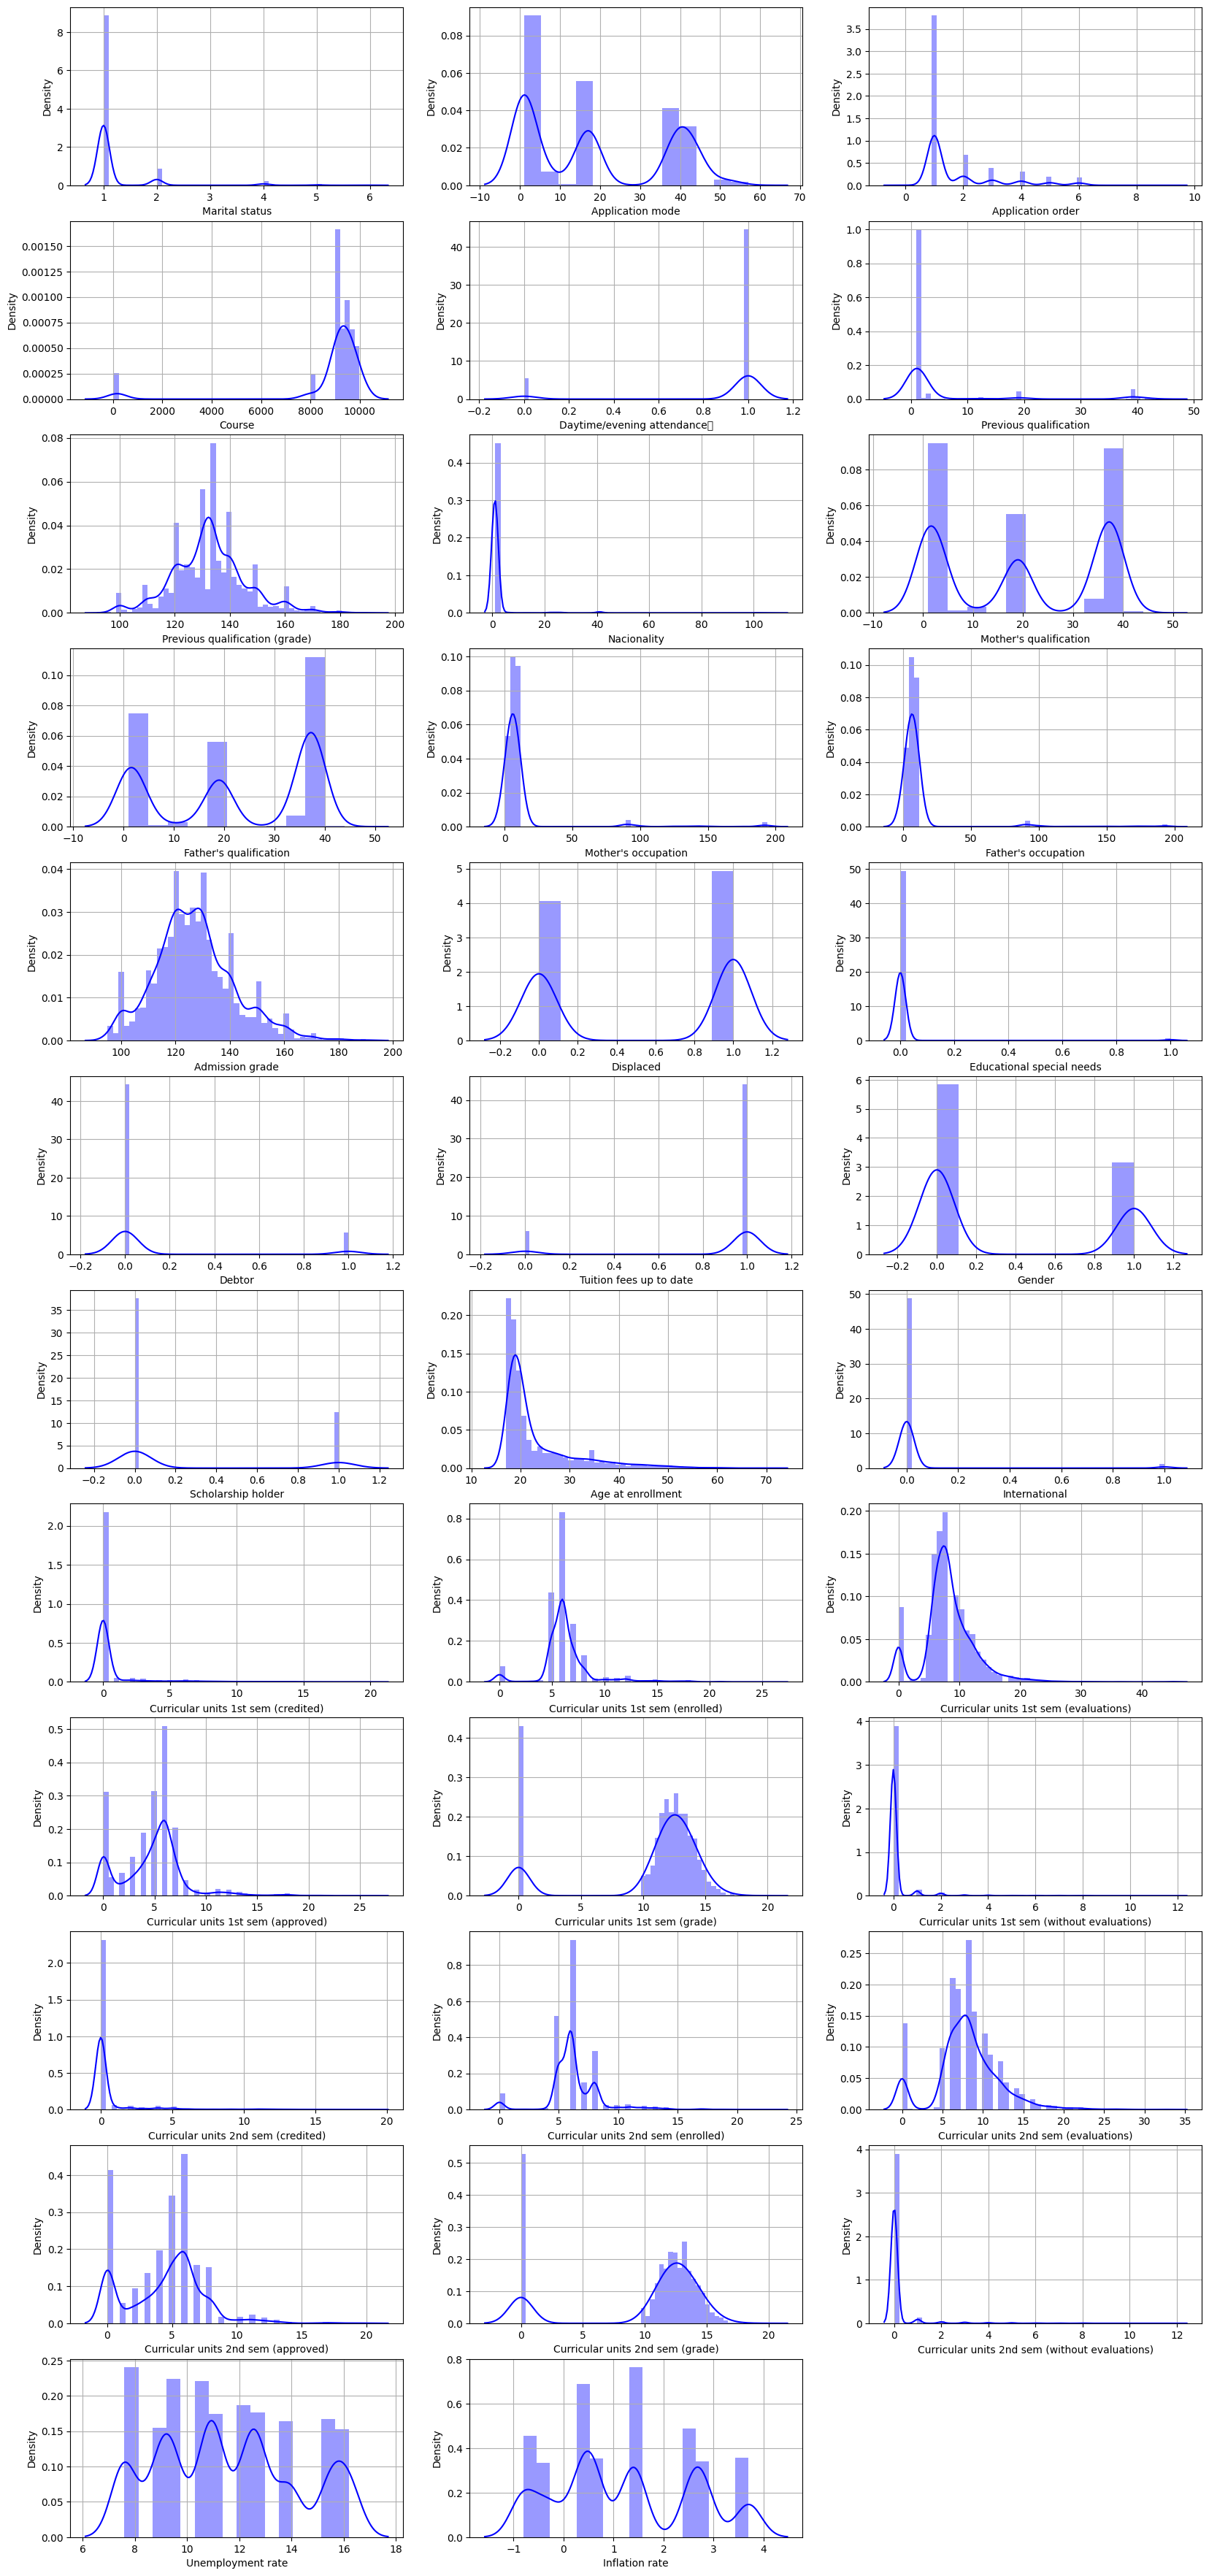

In [15]:
plt.figure(figsize=(20, 45))

for i in range(0, 35):
    plt.subplot(12,3,i+1)
    sns.distplot(df.iloc[:, i], color='blue')
    plt.grid()

c:\Users\praty\Documents\ML_LAB_PROJECT\Student-Dropout-Prediction-Tool\myenv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\praty\Documents\ML_LAB_PROJECT\Student-Dropout-Prediction-Tool\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


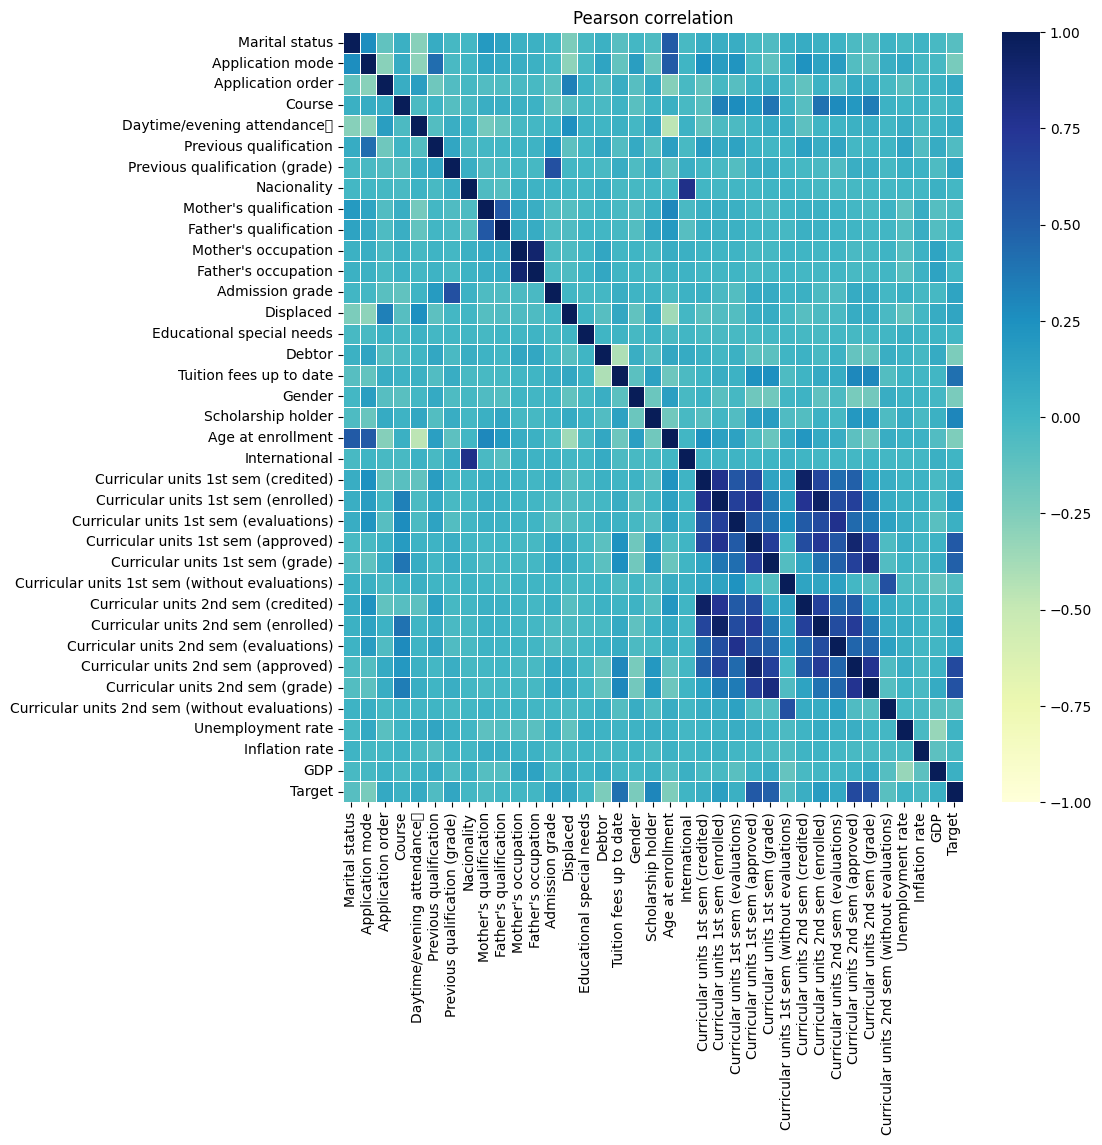

In [16]:
#feature selection
corr_matrix = df.corr(method="pearson")
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, vmin=-1., vmax=1., annot=False, fmt='.2f', cmap="YlGnBu", cbar=True, linewidths=0.5)
plt.title("Pearson correlation")
plt.show()

In [17]:
["Tuition fees up to date","Curricular units 1st sem (approved)","Curricular units 1st sem (grade)","Curricular units 2nd sem (approved)","Curricular units 2nd sem (grade)"]
corr_matrix["Target"]

Marital status                                   -0.089804
Application mode                                 -0.221747
Application order                                 0.089791
Course                                            0.034219
Daytime/evening attendance\t                      0.075107
Previous qualification                           -0.056039
Previous qualification (grade)                    0.103764
Nacionality                                      -0.014801
Mother's qualification                           -0.043178
Father's qualification                           -0.001393
Mother's occupation                              -0.005629
Father's occupation                              -0.001899
Admission grade                                   0.120889
Displaced                                         0.113986
Educational special needs                        -0.007353
Debtor                                           -0.240999
Tuition fees up to date                           0.4098

## **potential error**

### "Enrolled" student is irrelevant. We only need to know whether a student graduated or droped out. thus  the "Enrolled" values  are removed and only with "Graduate" & "Dropout" values used.

In [18]:
df.drop(df[df['Target'] == 1].index, inplace = True)
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,2
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,0
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,0
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,2


In [19]:
df['Dropout'] = df['Target'].apply(lambda x: 1 if x==0 else 0)
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Dropout
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,0,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,2,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,0,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,2,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,6,8,5,12.666667,0,15.5,2.8,-4.06,2,0
4420,1,1,2,9773,1,1,120.0,105,1,1,...,6,6,2,11.000000,0,11.1,0.6,2.02,0,1
4421,1,1,1,9500,1,1,154.0,1,37,37,...,8,9,1,13.500000,0,13.9,-0.3,0.79,0,1
4422,1,1,1,9147,1,1,180.0,1,37,37,...,5,6,5,12.000000,0,9.4,-0.8,-3.12,2,0


C:\Users\praty\AppData\Local\Temp\ipykernel_6768\692082763.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Dropout'], color = "red")


<Axes: xlabel='Dropout', ylabel='Density'>

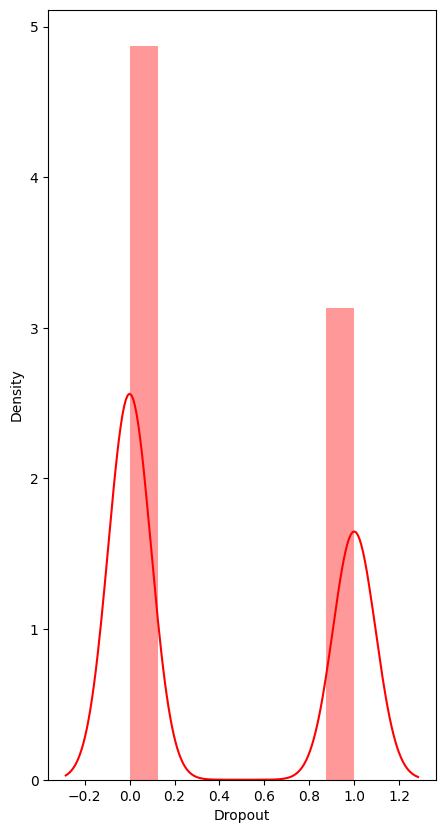

In [20]:
plt.figure(figsize=(5, 10))
sns.distplot(df['Dropout'], color = "red")

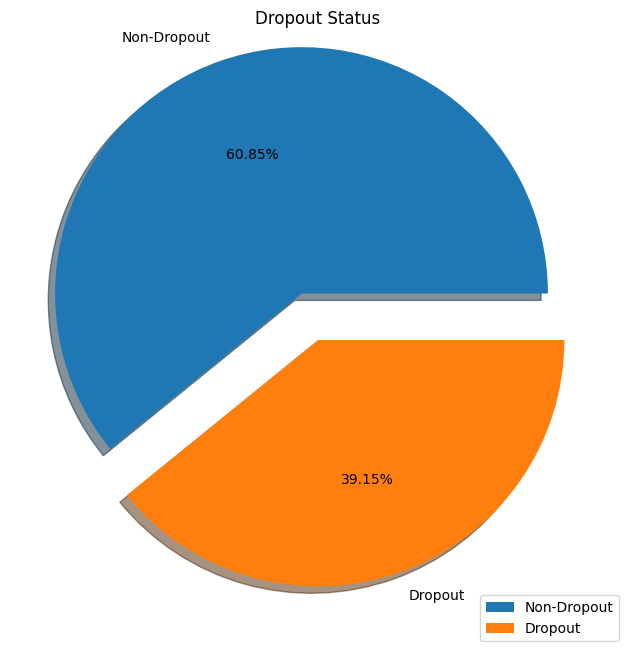

In [21]:
plt.figure(figsize=(8, 8))
plt.title("Dropout Status")
plt.pie(df['Dropout'].value_counts(),  labels = ['Non-Dropout', 'Dropout'], explode = (0.2, 0.0), autopct='%1.2f%%', shadow = True)
plt.legend( loc = 'lower right')

# first feature selection then Standard Scaling the Data normalize numerical values(scaling all features)

In [22]:
# ✅ INPUT FEATURES & TARGET
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# Extract X and y
x = df.iloc[:, :36].values
y = df['Dropout'].values

# FEATURE SELECTION: Keep top 10 most relevant features
selector = SelectKBest(score_func=f_classif, k=10)
x = selector.fit_transform(x, y)

# Display selected feature names
selected_columns = df.columns[:36][selector.get_support()]
print("✅ Selected Features:", selected_columns.tolist())

# STANDARDIZATION: Normalize selected features
x = StandardScaler().fit_transform(x)


✅ Selected Features: ['Application mode', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']


In [23]:
# y = df['Dropout'].values
# y

# Train & Test Splitting the Data

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

# Function to Measure Performance

In [25]:
def perform(y_pred):
    print("Precision : ", precision_score(y_test, y_pred, average = 'micro'))
    print("Recall : ", recall_score(y_test, y_pred, average = 'micro'))
    print("Accuracy : ", accuracy_score(y_test, y_pred))
    print("F1 Score : ", f1_score(y_test, y_pred, average = 'micro'))
    cm = confusion_matrix(y_test, y_pred)
    print("\n", cm)
    print("\n")
    print("**"*27 + "\n" + " "* 16 + "Classification Report\n" + "**"*27)
    print(classification_report(y_test, y_pred))
    print("**"*27+"\n")

    cm = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=['Non-Dropout', 'Dropout'])
    cm.plot()

# Gaussian Naive Bayes

In [26]:
model_nb = GaussianNB()
model_nb.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [27]:
y_pred_nb = model_nb.predict(x_test)

Precision :  0.8512396694214877
Recall :  0.8512396694214877
Accuracy :  0.8512396694214877
F1 Score :  0.8512396694214877

 [[412  36]
 [ 72 206]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       448
           1       0.85      0.74      0.79       278

    accuracy                           0.85       726
   macro avg       0.85      0.83      0.84       726
weighted avg       0.85      0.85      0.85       726

******************************************************



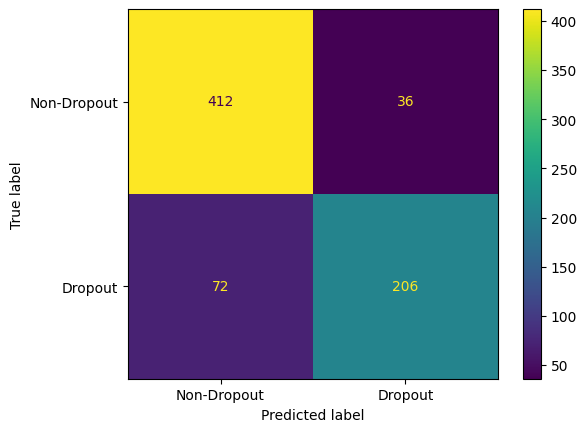

In [28]:
perform(y_pred_nb)

# Logistic Regression

In [29]:
model_lr = LogisticRegression()
model_lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
y_pred_lr = model_lr.predict(x_test)

Precision :  0.8939393939393939
Recall :  0.8939393939393939
Accuracy :  0.8939393939393939
F1 Score :  0.8939393939393939

 [[419  29]
 [ 48 230]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       448
           1       0.89      0.83      0.86       278

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.89       726
weighted avg       0.89      0.89      0.89       726

******************************************************



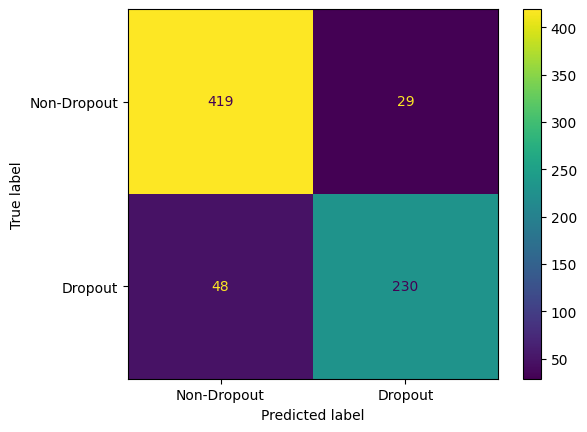

In [31]:
perform(y_pred_lr)

# Random Forest

In [32]:
model_rf = RandomForestClassifier(n_estimators=500,criterion='entropy')
model_rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [33]:
y_pred_rf = model_rf.predict(x_test)

Precision :  0.9159779614325069
Recall :  0.9159779614325069
Accuracy :  0.9159779614325069
F1 Score :  0.9159779614325069

 [[429  19]
 [ 42 236]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       448
           1       0.93      0.85      0.89       278

    accuracy                           0.92       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.92      0.92       726

******************************************************



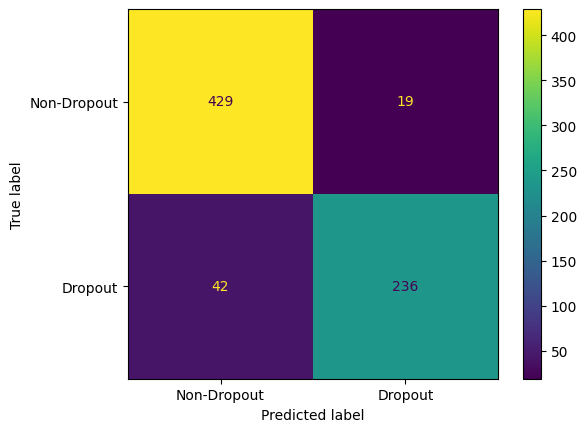

In [34]:
perform(y_pred_rf)

# Support Vector Classifier

In [35]:
model_svc = SVC(C=0.1,kernel='linear')
model_svc.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [36]:
y_pred_svc = model_svc.predict(x_test)

Precision :  0.8980716253443526
Recall :  0.8980716253443526
Accuracy :  0.8980716253443526
F1 Score :  0.8980716253443526

 [[428  20]
 [ 54 224]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       448
           1       0.92      0.81      0.86       278

    accuracy                           0.90       726
   macro avg       0.90      0.88      0.89       726
weighted avg       0.90      0.90      0.90       726

******************************************************



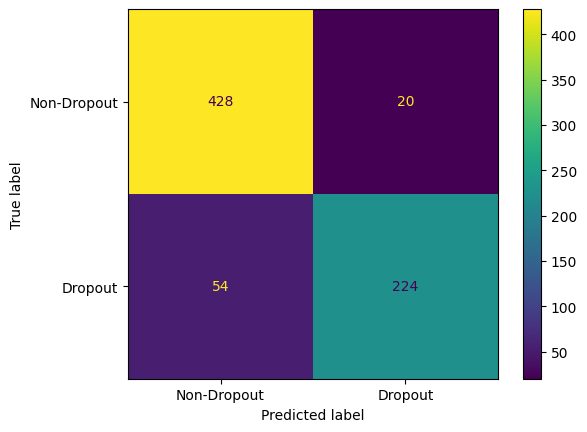

In [37]:
perform(y_pred_svc)

# KNN Classifier

In [38]:
error = []

# Calculating MAE error for K values between 1 and 39
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    accuracy = accuracy_score(y_test, pred_i)
    error.append(accuracy)
    # 🔍 Find the best K
best_k = error.index(max(error)) + 1
print(f" Best K value = {best_k}, Accuracy = {max(error):.4f}")


 Best K value = 9, Accuracy = 0.9036


Text(0, 0.5, 'Accuracy')

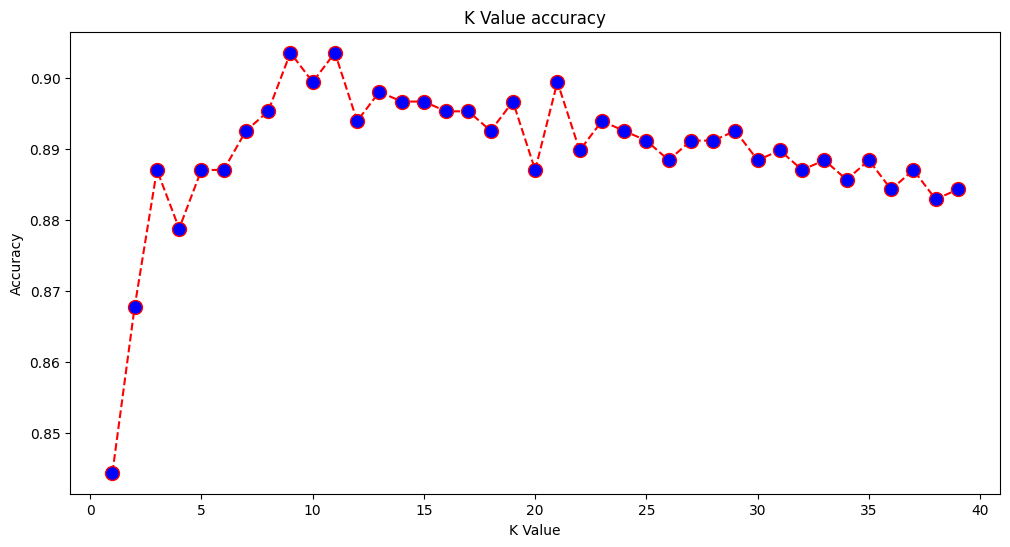

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red',
         linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)

plt.title('K Value accuracy')
plt.xlabel('K Value')
plt.ylabel('Accuracy')

In [40]:
model_knn = KNeighborsClassifier(n_neighbors=9)
model_knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
y_pred_knn = model_knn.predict(x_test)

Precision :  0.9035812672176309
Recall :  0.9035812672176309
Accuracy :  0.9035812672176309
F1 Score :  0.9035812672176309

 [[430  18]
 [ 52 226]]


******************************************************
                Classification Report
******************************************************
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       448
           1       0.93      0.81      0.87       278

    accuracy                           0.90       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.90      0.90       726

******************************************************



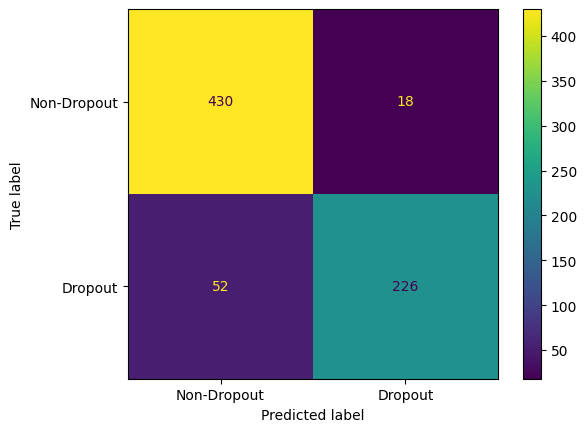

In [42]:
perform(y_pred_knn)

# XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=1
)
model_xgb.fit(x_train, y_train)
print('XGBoost model trained successfully.')

In [ ]:
y_pred_xgb = model_xgb.predict(x_test)

In [ ]:
perform(y_pred_xgb)

# Comparison

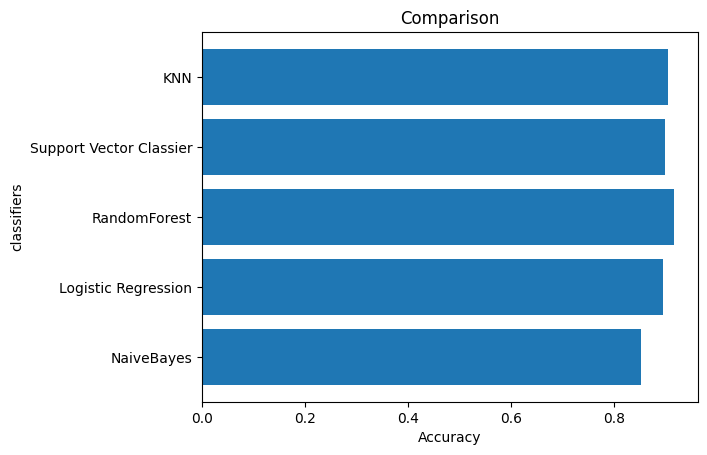

In [43]:
pred=[y_pred_nb, y_pred_lr, y_pred_rf, y_pred_svc, y_pred_knn, y_pred_xgb]
acc=[]
classifiers=["Naive Bayes", "Logistic Regression", "Random Forest", "SVM", "KNN", "XGBoost"]
for i in pred:
    temp=accuracy_score(y_test, i)
    acc.append(temp)

plt.figure(figsize=(10, 6))
plt.barh(classifiers, acc, color=['steelblue','tomato','forestgreen','darkorange','mediumpurple','crimson'])
for idx, v in enumerate(acc):
    plt.text(v + 0.001, idx, f'{v:.4f}', va='center', fontsize=9)
plt.xlabel('Accuracy')
plt.ylabel('Classifiers')
plt.title('Model Accuracy Comparison (including XGBoost)')
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()


# Comaprison tile

🔍 Model Performance Comparison:

                     Accuracy  Precision    Recall  F1 Score
Model                                                       
Naive Bayes          0.851240   0.851240  0.851240  0.851240
Logistic Regression  0.893939   0.893939  0.893939  0.893939
Random Forest        0.907713   0.907713  0.907713  0.907713
SVC                  0.899449   0.899449  0.899449  0.899449
KNN                  0.903581   0.903581  0.903581  0.903581


<Axes: title={'center': 'Model Comparison'}, xlabel='Model'>

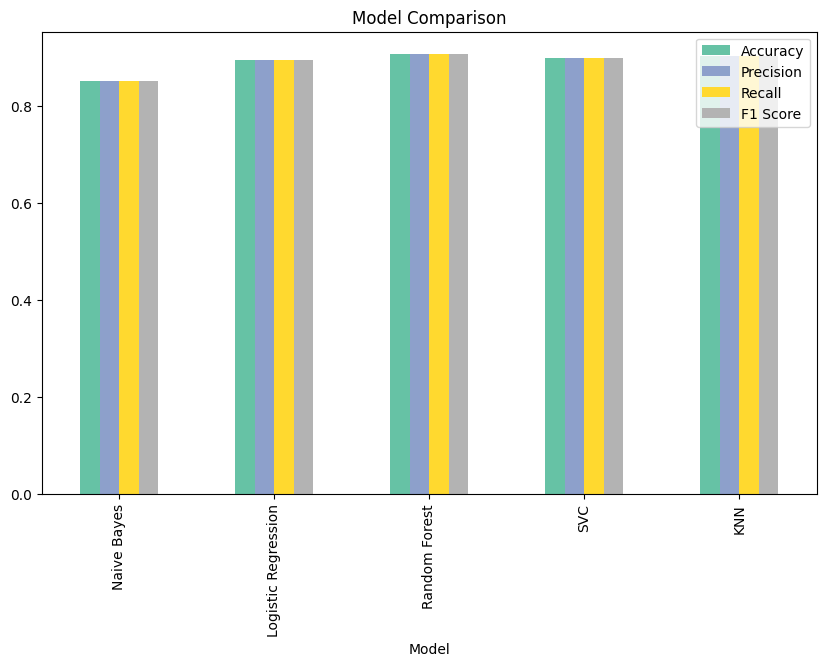

In [44]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Assuming you have already split your data into x and y
# Split the data into training and testing sets (this step must be done before model training)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

# Initialize the models
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, use_label_encoder=False, eval_metric="logloss", random_state=1)
}

# Dictionary to store predictions
model_results = {}

# Train models and generate predictions
for name, model in models.items():
    # Train the model on the training data
    model.fit(x_train, y_train)

    # Make predictions on the test data
    y_pred = model.predict(x_test)

    # Store predictions in the dictionary
    model_results[name] = y_pred

# Create a comparison table to evaluate model performance
comparison = []

for name, pred in model_results.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='micro')
    rec = recall_score(y_test, pred, average='micro')
    f1 = f1_score(y_test, pred, average='micro')
    comparison.append([name, acc, prec, rec, f1])

# Convert to DataFrame for easier visualization
df_results = pd.DataFrame(comparison, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
df_results.set_index("Model", inplace=True)

# Display the results
print("🔍 Model Performance Comparison:\n")
print(df_results)

# Optional: Plot the results for better visualization
df_results.plot(kind='bar', figsize=(10,6), title="Model Comparison", colormap='Set2')




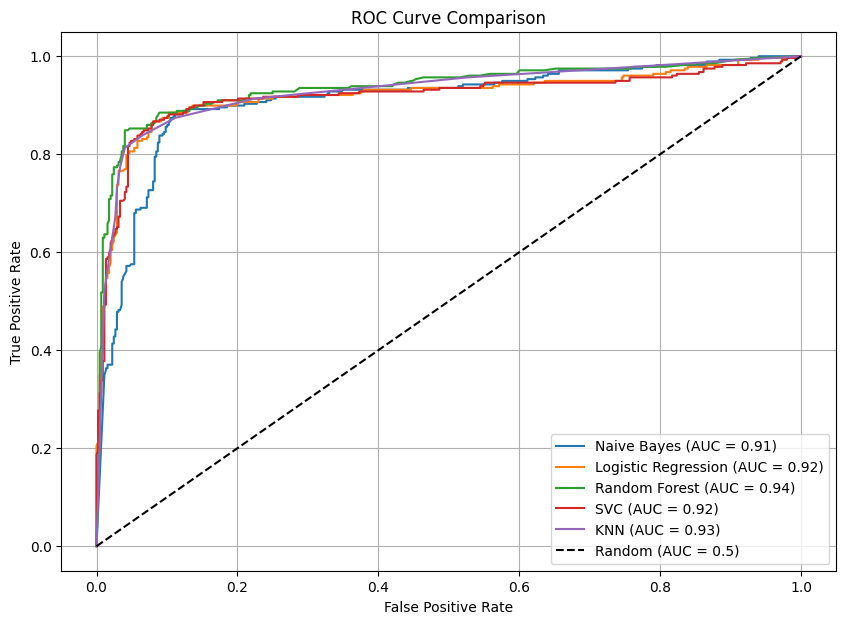

📊 Updated Model Comparison with AUC:
                     Accuracy  Precision    Recall  F1 Score       AUC
Model                                                                 
Naive Bayes          0.851240   0.851240  0.851240  0.851240  0.909502
Logistic Regression  0.893939   0.893939  0.893939  0.893939  0.920470
Random Forest        0.907713   0.907713  0.907713  0.907713  0.937247
SVC                  0.899449   0.899449  0.899449  0.899449  0.918326
KNN                  0.903581   0.903581  0.903581  0.903581  0.929463


In [45]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# For models that can output probabilities
model_probas = {
    "Naive Bayes": model_nb.predict_proba(x_test)[:,1],
    "Logistic Regression": model_lr.predict_proba(x_test)[:,1],
    "Random Forest": model_rf.predict_proba(x_test)[:,1],
    "SVC": model_svc.decision_function(x_test),  # because it's not probabilistic
    "KNN": model_knn.predict_proba(x_test)[:,1],
    "XGBoost": model_xgb.predict_proba(x_test)[:,1]
}

# Plot ROC curves
plt.figure(figsize=(10, 7))
for name, prob in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Add AUC scores to comparison table
for name, prob in model_probas.items():
    auc_score = roc_auc_score(y_test, prob)
    df_results.loc[name, 'AUC'] = auc_score

# Show updated comparison table
print("📊 Updated Model Comparison with AUC:")
print(df_results)


# grado o/p with randomforest

In [47]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=500, criterion='entropy')
model_rf.fit(x_train, y_train)
# Check if RandomForest model has been fitted (trained)
if hasattr(model_rf, 'feature_importances_'):
    print("Model is trained.")
else:
    print("Model is not trained.")



Model is trained.


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_test_pred = model_rf.predict(x_test)

# Evaluate performance
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
# Sample input for prediction (must match the selected features)
sample_input = np.array([18, 0, 1, 1, 1, 19, 4, 14, 5, 15]).reshape(1, -1)
prediction = model_rf.predict(sample_input)
print(f"Sample prediction: {prediction}")


Accuracy: 0.9132
Precision: 0.9183
Recall: 0.8489
F1 Score: 0.8822
Sample prediction: [0]


In [49]:
# For RandomForestClassifier, check the predicted probabilities for the test data
probabilities = model_rf.predict_proba(x_test)[:, 1]
print(probabilities[:10])  # Print the first 10 predicted probabilities


[0.216      0.194      0.116      0.066      0.072      0.85888362
 0.082      0.552      0.468      0.378     ]


In [50]:
# Adjust the decision threshold for dropout prediction
threshold = 0.3  # You can try different threshold values
predictions = (probabilities >= threshold).astype(int)

# Display the adjusted predictions
print(predictions[:10])


[0 0 0 0 0 1 0 1 1 1]


In [51]:
import gradio as gr
import numpy as np

# Define your trained model
model = model_rf  # Replace with your trained model (model_rf)

# Define the selected feature names
feature_names = [
    "Application mode", "Debtor", "Tuition fees up to date", "Gender",
    "Scholarship holder", "Age at enrollment", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)"
]

# Prediction function that uses the trained model
def predict_dropout(application_mode, debtor, tuition_fees_up_to_date, gender, scholarship_holder,
                    age_at_enrollment, curr_units_1st_sem_approved, curr_units_1st_sem_grade,
                    curr_units_2nd_sem_approved, curr_units_2nd_sem_grade):
    # Convert inputs to a numpy array (reshaped to match model's expected input)
    input_array = np.array([[
        application_mode, debtor, tuition_fees_up_to_date, gender, scholarship_holder,
        age_at_enrollment, curr_units_1st_sem_approved, curr_units_1st_sem_grade,
        curr_units_2nd_sem_approved, curr_units_2nd_sem_grade
    ]])

    # Make the prediction
    prediction = model.predict(input_array)[0]

    # Return the result as a string (dropout or likely to graduate)
    return "⚠️ Dropout Risk" if prediction == 1 else "✅ Likely to Graduate"

# Create Gradio interface
inputs = [
    gr.Number(label="Application mode (1=Online, 2=In-person)", value=1),
    gr.Checkbox(label="Debtor (Yes=1, No=0)", value=False),
    gr.Checkbox(label="Tuition fees up to date (Yes=1, No=0)", value=True),
    gr.Checkbox(label="Gender (Male=1, Female=0)", value=False),  # Gender as checkbox (0=Female, 1=Male)
    gr.Checkbox(label="Scholarship holder (Yes=1, No=0)", value=False),
    gr.Number(label="Age at enrollment", value=20),
    gr.Number(label="Curricular units 1st semester (approved)", value=5),
    gr.Number(label="Curricular units 1st semester (grade)", value=14),
    gr.Number(label="Curricular units 2nd semester (approved)", value=4),
    gr.Number(label="Curricular units 2nd semester (grade)", value=13)
]

# Launch the Gradio interface
gr.Interface(
    fn=predict_dropout,  # The function that handles predictions
    inputs=inputs,       # The input fields for the model
    outputs=gr.Textbox(label="Prediction Result"),  # Output to show the prediction result
    title="🎓 Student Dropout Predictor",
    description="Enter student details to predict the risk of dropout based on trained data."
).launch()


c:\Users\praty\Documents\ML_LAB_PROJECT\Student-Dropout-Prediction-Tool\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [52]:
# import gradio as gr
# import numpy as np

# # Use your trained model here (replace with model_rf or model_nn)
# model = model_rf  # Or model_nn

# # Define input labels
# feature_names = [
#     "Marital status", "Application mode", "Application order", "Course",
#     "Daytime/evening attendance", "Previous qualification", "Previous qualification grade",
#     "Nacionality", "Mother's qualification", "Father's qualification", "Mother's occupation",
#     "Father's occupation", "Admission grade", "Displaced", "Educational special needs",
#     "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "Age at enrollment",
#     "International", "Unemployment rate", "Inflation rate", "GDP"
# ]

# def predict_dropout(*inputs):
#     input_array = np.array(inputs).reshape(1, -1)
#     prediction = model.predict(input_array)[0]
#     return "⚠️ Dropout Risk" if prediction == 1 else "✅ Likely to Graduate"

# inputs = [gr.Number(label=label) for label in feature_names]

# gr.Interface(
#     fn=predict_dropout,
#     inputs=inputs,
#     outputs=gr.Textbox(label="Prediction Result"),
#     title="🎓 Student Dropout Predictor",
#     description="Enter student details to predict dropout risk using the trained ML model."
# ).launch()


In [56]:
df.info()


<class 'pandas.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Course                                          3630 non-null   int64  
 4   Daytime/evening attendance	                     3630 non-null   int64  
 5   Previous qualification                          3630 non-null   int64  
 6   Previous qualification (grade)                  3630 non-null   float64
 7   Nacionality                                     3630 non-null   int64  
 8   Mother's qualification                          3630 non-null   int64  
 9   Father's qualification                          3630 non-